### LSTM 

Epoch 1, Train: 2782102.86, Val: 107385.41
Epoch 2, Train: 1070383.45, Val: 121492.55
Epoch 3, Train: 1007882.11, Val: 119738.25
Epoch 4, Train: 944746.38, Val: 109513.88
Epoch 5, Train: 911903.39, Val: 104499.51
Epoch 6, Train: 913276.96, Val: 107677.22
Epoch 7, Train: 938866.08, Val: 111792.12
Epoch 8, Train: 895094.73, Val: 105321.39
Epoch 9, Train: 889724.06, Val: 95265.40
Epoch 10, Train: 869103.48, Val: 98323.93
Epoch 11, Train: 891856.53, Val: 117028.80
Epoch 12, Train: 909537.49, Val: 99879.53
Epoch 13, Train: 870307.03, Val: 97990.89
Epoch 14, Train: 887775.65, Val: 116378.42
Epoch 15, Train: 926201.62, Val: 98248.95
Epoch 16, Train: 896780.84, Val: 109140.25
Epoch 17, Train: 853833.51, Val: 103278.44
Epoch 18, Train: 854764.72, Val: 97289.16
Epoch 19, Train: 902212.07, Val: 106568.81
Epoch 20, Train: 883216.37, Val: 103983.83
Epoch 21, Train: 865577.51, Val: 95411.45
Epoch 22, Train: 862054.92, Val: 109821.24
Epoch 23, Train: 883093.50, Val: 100854.72
Epoch 24, Train: 838861.

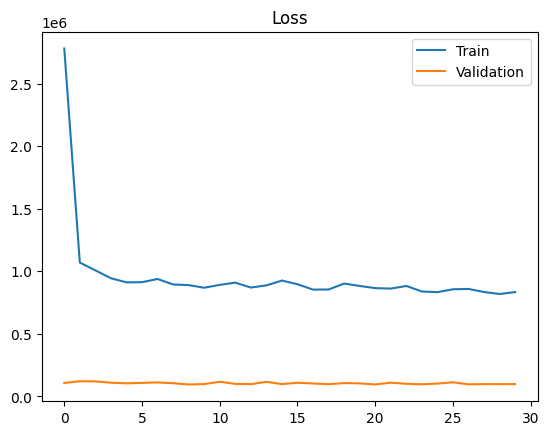

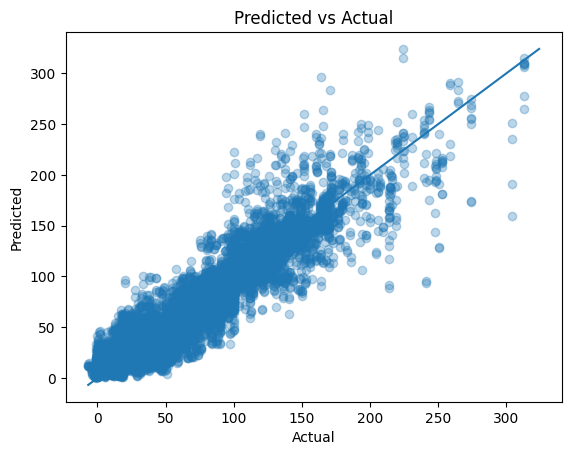

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


df_main = pd.read_csv("fucking_clean_ass_data_bitch.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

# Rename columns
dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

# Merge
df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")

target_col = "value"


df["lag_1"] = df[target_col].shift(1)
df["lag_2"] = df[target_col].shift(2)
df["lag_24"] = df[target_col].shift(24)


df["hour"] = df["datetime"].dt.hour


df["target"] = df[target_col].shift(-1)


df = df.ffill()

# Drop useless column
df = df.drop(columns=["unit"], errors="ignore")

df["isEstimated"] = df["isEstimated"].astype(int)

# One-hot encode important categorical columns
one_hot_cols = [
    "zone_prev",
    "source",
    "zone_CI",
    "emissionFactorType",
    "estimationMethod"
]

existing_cols = [c for c in one_hot_cols if c in df.columns]
df = pd.get_dummies(df, columns=existing_cols, drop_first=True)

# Encode import/export safely
for col in ["import", "export"]:
        df[col] = df[col].astype("category").cat.codes

# Drop datetime AFTER feature creation
df = df.drop(columns=["datetime"], errors="ignore")

df = df.dropna()

X = df.drop(columns=["target"]).values
y = df["target"].values


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
y_train, y_val, y_test = y[:split1], y[split1:split2], y[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences(X, y, seq_len=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 24

X_train, y_train = create_sequences(X_train, y_train, SEQ_LEN)
X_val, y_val = create_sequences(X_val, y_val, SEQ_LEN)
X_test, y_test = create_sequences(X_test, y_test, SEQ_LEN)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, y_val), batch_size=32)
test_loader  = DataLoader(SeqDataset(X_test, y_test), batch_size=32)

class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 30
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            val_loss += criterion(model(X_batch), y_batch).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds.extend(model(X_batch).numpy())
        actuals.extend(y_batch.numpy())

preds = np.array(preds).flatten()
actuals = np.array(actuals).flatten()

mae = np.mean(np.abs(preds - actuals))
rmse = np.sqrt(np.mean((preds - actuals) ** 2))

print("\nFINAL RESULTS")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()


plt.figure()
plt.scatter(actuals, preds, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()